---
# 🚀 EXTENSION TASKS

---
## 🦙 Extension 1: LlamaIndex RAG — Compare Retrieval Faithfulness

Why it's used


*   Validates retrieval quality across frameworks.

*   Compares LangChain+FAISS against LlamaIndex+BGE embeddings.
*   Ensures the RAG system retrieves relevant policy documents consistently.






In [ ]:
from llama_index.core import VectorStoreIndex, Document as LIDocument, Settings
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.core.node_parser import SentenceSplitter
from llama_index.core.evaluation import FaithfulnessEvaluator

print("Building LlamaIndex knowledge base...")

# Configure embeddings (no OpenAI required)
Settings.embed_model = HuggingFaceEmbedding(model_name='BAAI/bge-small-en-v1.5')
Settings.llm = None  # We'll handle LLM separately

li_documents = [
    LIDocument(text=doc['content'], metadata={'title': doc['title'], 'id': doc['id']})
    for doc in POLICY_DOCS
]

li_index = VectorStoreIndex.from_documents(
    li_documents,
    transformations=[SentenceSplitter(chunk_size=400, chunk_overlap=50)]
)

li_retriever = li_index.as_retriever(similarity_top_k=3)

print("✅ LlamaIndex index built")

# Compare retrieval between LangChain FAISS and LlamaIndex
comparison_queries = [
    "What is the minimum credit score for a loan?",
    "What are the DPDP data retention rules?",
    "How is EMI calculated?",
]

print("\n📊 RETRIEVAL COMPARISON — LangChain FAISS vs. LlamaIndex BGE")
print("=" * 70)

for q in comparison_queries:
    # LangChain
    lc_docs = retriever.invoke(q)
    lc_titles = [d.metadata.get('title', 'Unknown')[:40] for d in lc_docs]

    # LlamaIndex
    li_nodes = li_retriever.retrieve(q)
    li_titles = [n.metadata.get('title', 'Unknown')[:40] for n in li_nodes]

    print(f"\nQuery: {q}")
    print(f"  LangChain: {lc_titles}")
    print(f"  LlamaIndex: {li_titles}")
    overlap = set(lc_titles) & set(li_titles)
    print(f"  Overlap: {len(overlap)}/{max(len(lc_titles),len(li_titles))} docs")

Building LlamaIndex knowledge base...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

LLM is explicitly disabled. Using MockLLM.
✅ LlamaIndex index built

📊 RETRIEVAL COMPARISON — LangChain FAISS vs. LlamaIndex BGE

Query: What is the minimum credit score for a loan?
  LangChain: ['RBI Master Circular — Credit Policy for ', 'FinanceGuard Internal Loan Product Guide', 'RBI Master Circular — Credit Policy for ']
  LlamaIndex: ['FinanceGuard Internal Loan Product Guide', 'RBI Master Circular — Credit Policy for ', 'Fraud Prevention and AML Guidelines']
  Overlap: 2/3 docs

Query: What are the DPDP data retention rules?
  LangChain: ['Data Privacy Policy — DPDP Act 2023 Comp', 'Data Privacy Policy — DPDP Act 2023 Comp', 'Fraud Prevention and AML Guidelines']
  LlamaIndex: ['Data Privacy Policy — DPDP Act 2023 Comp', 'Fraud Prevention and AML Guidelines', 'RBI Master Circular — Credit Policy for ']
  Overlap: 2/3 docs

Query: How is EMI calculated?
  LangChain: ['EMI Calculation and Loan Structuring Gui', 'EMI Calculation and Loan Structuring Gui', 'Fraud Prevention and AML 

Output


*   Retrieved document titles from both systems.

*   Overlap score showing how many documents both retrievers selected.
*   Higher overlap suggests stronger retrieval consistency.







## 🔄 Extension 2: LangGraph Human-in-the-Loop

Why it's used


*   Financial decisions often require human oversight.
*   High-value or high-risk applications are routed for manual review.




Business Rules


*   Loan ≥ ₹10 lakh → Human review
*   Risk score ≥ 0.70 → Human review





In [ ]:
# LangGraph HITL pattern for high-value loans (> INR 10 lakhs)
# Simulated here — in production this would trigger a real review workflow.

from enum import Enum

class ReviewDecision(Enum):
    APPROVE  = "approve"
    REJECT   = "reject"
    ESCALATE = "escalate"

@dataclass
class LoanRequest:
    application_id: str
    loan_amount: float
    applicant_summary: str
    ai_recommendation: str
    risk_score: float
    review_required: bool = False
    human_decision: Optional[ReviewDecision] = None
    reviewer_id: Optional[str] = None
    review_notes: Optional[str] = None


class HITLWorkflow:
    """
    Human-in-the-loop workflow inspired by LangGraph patterns.
    High-value or high-risk loans pause for human approval.
    """
    HIGH_VALUE_THRESHOLD = 1_000_000   # INR 10 lakhs
    HIGH_RISK_SCORE      = 0.7
    REVIEW_QUEUE         = []

    def route(self, request: LoanRequest) -> str:
        """Routing node — decides if human review is needed."""
        if (request.loan_amount >= self.HIGH_VALUE_THRESHOLD or
                request.risk_score >= self.HIGH_RISK_SCORE):
            request.review_required = True
            self.REVIEW_QUEUE.append(request)
            return 'human_review'
        return 'auto_process'

    def human_review_node(self, request: LoanRequest,
                          decision: ReviewDecision, reviewer: str, notes: str = ''):
        """Simulates a human reviewer approving or rejecting the request."""
        request.human_decision = decision
        request.reviewer_id    = reviewer
        request.review_notes   = notes
        if request in self.REVIEW_QUEUE:
            self.REVIEW_QUEUE.remove(request)
        return request

    def queue_status(self):
        print(f"\n📋 REVIEW QUEUE STATUS: {len(self.REVIEW_QUEUE)} pending")
        for r in self.REVIEW_QUEUE:
            print(f"   [{r.application_id}] INR {r.loan_amount:,.0f} | Risk: {r.risk_score:.2f} | {r.applicant_summary[:50]}")


# Simulate the HITL workflow
hitl = HITLWorkflow()

test_loans = [
    LoanRequest('APP100301', 500_000,   'Salaried, credit score 720, DTI 30%', 'Likely approve', 0.25),
    LoanRequest('APP100302', 1_500_000, 'Self-employed, credit score 660, DTI 45%', 'Borderline', 0.62),
    LoanRequest('APP100303', 200_000,   'Salaried, credit score 580, DTI 55%', 'High risk', 0.82),
    LoanRequest('APP100304', 800_000,   'Salaried, credit score 750, DTI 25%', 'Likely approve', 0.18),
]

print("\n🔄 LANGRAPH-STYLE HITL ROUTING")
print("-" * 65)
for loan in test_loans:
    route = hitl.route(loan)
    icon = "🔄" if route == 'human_review' else "⚡"
    print(f"{icon} [{route.upper():14}] [{loan.application_id}] INR {loan.loan_amount:>12,.0f} | Risk: {loan.risk_score:.2f}")

hitl.queue_status()

# Simulate human reviews
print("\n👤 Simulating human review decisions...")
review_queue_copy = hitl.REVIEW_QUEUE.copy()
for i, req in enumerate(review_queue_copy):
    decision = ReviewDecision.APPROVE if req.risk_score < 0.70 else ReviewDecision.REJECT
    hitl.human_review_node(req, decision, f'UNDERWRITER_{i+1:03d}', 'Manual review complete')
    print(f"   [{req.application_id}] → {decision.value.upper()} by UNDERWRITER_{i+1:03d}")

hitl.queue_status()


🔄 LANGRAPH-STYLE HITL ROUTING
-----------------------------------------------------------------
⚡ [AUTO_PROCESS  ] [APP100301] INR      500,000 | Risk: 0.25
🔄 [HUMAN_REVIEW  ] [APP100302] INR    1,500,000 | Risk: 0.62
🔄 [HUMAN_REVIEW  ] [APP100303] INR      200,000 | Risk: 0.82
⚡ [AUTO_PROCESS  ] [APP100304] INR      800,000 | Risk: 0.18

📋 REVIEW QUEUE STATUS: 2 pending
   [APP100302] INR 1,500,000 | Risk: 0.62 | Self-employed, credit score 660, DTI 45%
   [APP100303] INR 200,000 | Risk: 0.82 | Salaried, credit score 580, DTI 55%

👤 Simulating human review decisions...
   [APP100302] → APPROVE by UNDERWRITER_001
   [APP100303] → REJECT by UNDERWRITER_002

📋 REVIEW QUEUE STATUS: 0 pending


Output


*   AUTO_PROCESS for low-risk applications.
*   HUMAN_REVIEW for applications requiring manual approval.


*   Review queue status showing pending reviews.





## 💰 Extension 3: Cost Benchmarking — GPT-4o vs. Llama-3

Why it's used


*   Estimates production costs at scale.
*   Helps select the most cost-efficient model.






💰 COST BENCHMARK — 80,000 queries/day | 200 in + 300 out tokens
             name        type  latency_ms  daily_cost_usd  monthly_cost_usd
           GPT-4o         API         800            $280             $8400
      GPT-4o-mini         API         400             $17              $504
 Gemini 1.5 Flash         API         350              $8              $252
Llama-3-70B (API)         API         600             $28              $852
 Llama-3-8B (API)         API         200              $8              $240
Llama-3-70B (GPU) Self-hosted         900             $16              $480


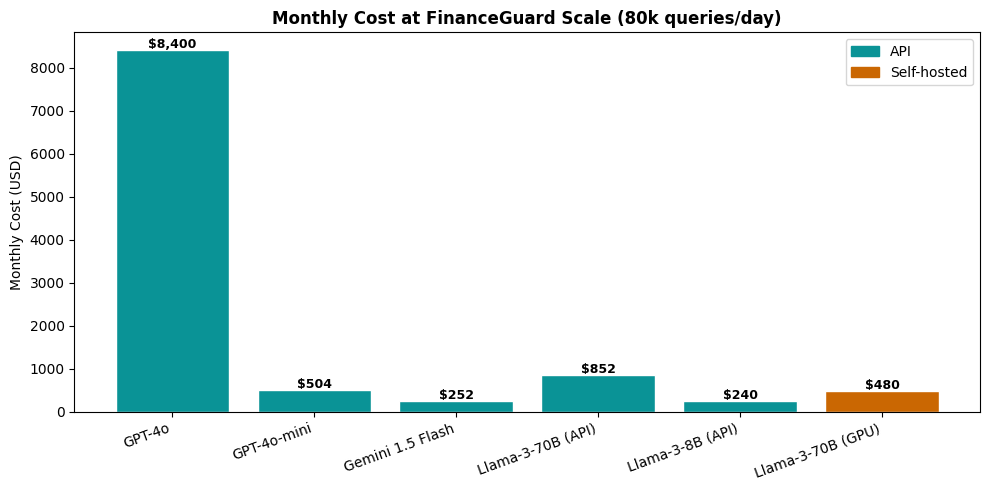


💡 GPT-4o → Llama-3-8B saves $8,160/month (97% reduction)


In [ ]:
# Cost comparison based on real 2025 pricing
# Source: OpenAI pricing page + Fireworks AI / Together AI self-hosted estimates

MODELS = [
    {'name': 'GPT-4o',            'input': 2.50,  'output': 10.00, 'latency_ms': 800,  'type': 'API'},
    {'name': 'GPT-4o-mini',       'input': 0.15,  'output': 0.60,  'latency_ms': 400,  'type': 'API'},
    {'name': 'Gemini 1.5 Flash',  'input': 0.075, 'output': 0.30,  'latency_ms': 350,  'type': 'API'},
    {'name': 'Llama-3-70B (API)', 'input': 0.59,  'output': 0.79,  'latency_ms': 600,  'type': 'API'},
    {'name': 'Llama-3-8B (API)',  'input': 0.20,  'output': 0.20,  'latency_ms': 200,  'type': 'API'},
    {'name': 'Llama-3-70B (GPU)', 'input': 0.40,  'output': 0.40,  'latency_ms': 900,  'type': 'Self-hosted'},
]

# Simulate 80,000 daily queries (FinanceGuard's actual volume)
# Avg: 200 input tokens, 300 output tokens per query
DAILY_QUERIES  = 80_000
AVG_IN_TOKENS  = 200
AVG_OUT_TOKENS = 300

results = []
for m in MODELS:
    daily_input_cost  = (DAILY_QUERIES * AVG_IN_TOKENS  / 1_000_000) * m['input']
    daily_output_cost = (DAILY_QUERIES * AVG_OUT_TOKENS / 1_000_000) * m['output']
    daily_cost        = daily_input_cost + daily_output_cost
    monthly_cost      = daily_cost * 30
    results.append({**m, 'daily_cost_usd': daily_cost, 'monthly_cost_usd': monthly_cost})

df_cost = pd.DataFrame(results)
print("\n💰 COST BENCHMARK — 80,000 queries/day | 200 in + 300 out tokens")
print(df_cost[['name', 'type', 'latency_ms', 'daily_cost_usd', 'monthly_cost_usd']].to_string(
    index=False,
    float_format=lambda x: f"${x:.0f}" if x > 1 else f"${x:.2f}"
))

# Visualise
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#0A9396' if t == 'API' else '#CA6702' for t in df_cost['type']]
bars = ax.bar(df_cost['name'], df_cost['monthly_cost_usd'], color=colors, edgecolor='white')
ax.set_title('Monthly Cost at FinanceGuard Scale (80k queries/day)', fontweight='bold')
ax.set_ylabel('Monthly Cost (USD)')
ax.set_xticklabels(df_cost['name'], rotation=20, ha='right')
for bar, val in zip(bars, df_cost['monthly_cost_usd']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f'${val:,.0f}', ha='center', fontsize=9, fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#0A9396', label='API'), Patch(color='#CA6702', label='Self-hosted')])
plt.tight_layout()
plt.show()

gpt4o_cost = df_cost[df_cost['name'] == 'GPT-4o']['monthly_cost_usd'].values[0]
llama_cost = df_cost[df_cost['name'] == 'Llama-3-8B (API)']['monthly_cost_usd'].values[0]
print(f"\n💡 GPT-4o → Llama-3-8B saves ${gpt4o_cost - llama_cost:,.0f}/month ({(1 - llama_cost/gpt4o_cost):.0%} reduction)")

Output


*   Daily and monthly cost estimates.

*   Latency comparisons.


*   Savings calculations (e.g., GPT-4o vs Llama-3-8B).






## 🌐 Extension 4: FastAPI Wrapper with Rate Limiting

Why it's used


*   Converts the notebook prototype into a deployable API.
*   Adds request validation and abuse protection.





In [ ]:
# Full FastAPI application for CreditLens
# To run: save as app.py and execute `uvicorn app:app --reload`

fastapi_app_code = '''
from fastapi import FastAPI, HTTPException, Request, Depends
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel, Field
from typing import Optional
import time
from collections import defaultdict

app = FastAPI(
    title="CreditLens API",
    description="FinanceGuard AI Credit Policy Assistant — with safety guardrails",
    version="1.0.0"
)

app.add_middleware(
    CORSMiddleware,
    allow_origins=["https://financeGuard.internal"],
    allow_credentials=True,
    allow_methods=["POST"],
    allow_headers=["*"],
)

# ── In-memory rate limiter ────────────────────────────────────
RATE_LIMIT      = 30   # max requests per window
WINDOW_SECONDS  = 60
request_counts  = defaultdict(list)

def rate_limit_check(request: Request):
    client_ip = request.client.host
    now = time.time()
    window_start = now - WINDOW_SECONDS

    # Prune old timestamps
    request_counts[client_ip] = [
        t for t in request_counts[client_ip] if t > window_start
    ]

    if len(request_counts[client_ip]) >= RATE_LIMIT:
        raise HTTPException(
            status_code=429,
            detail=f"Rate limit exceeded: {RATE_LIMIT} requests per {WINDOW_SECONDS}s"
        )
    request_counts[client_ip].append(now)

# ── Request / Response models ─────────────────────────────────
class QueryRequest(BaseModel):
    query: str = Field(..., min_length=5, max_length=1000,
                       description="Natural language credit policy question")
    user_id: str = Field(..., description="Loan officer employee ID")
    application_context: Optional[str] = Field(None, description="Optional application ID for context")

class QueryResponse(BaseModel):
    query_id: str
    response: str
    action: str          # answered | blocked | redirected
    latency_ms: float
    pii_redacted: bool
    safety_passed: bool

# ── Endpoints ─────────────────────────────────────────────────
@app.post("/v1/query", response_model=QueryResponse)
async def query_creditlens(
    body: QueryRequest,
    _: None = Depends(rate_limit_check)
):
    result = pipeline.run(body.query, user_id=body.user_id)
    m = result["metrics"]
    return QueryResponse(
        query_id=result["query_id"],
        response=result["response"],
        action=result["action"],
        latency_ms=m.latency_ms,
        pii_redacted=m.pii_redacted,
        safety_passed=m.output_safety_safe
    )

@app.get("/health")
def health(): return {"status": "ok", "service": "CreditLens"}

@app.get("/v1/metrics")
def get_metrics():
    df = pipeline.metrics_dataframe()
    if df.empty: return {"total": 0}
    return {
        "total_queries": len(df),
        "block_rate": (df["final_action"] == "block").mean(),
        "avg_latency_ms": df["latency_ms"].mean(),
        "pii_redaction_rate": df["pii_redacted"].mean(),
        "estimated_daily_cost_usd": df["estimated_cost_usd"].sum()
    }
'''

print("FastAPI application code:")
print(fastapi_app_code)

# Save to file
with open('creditlens_app.py', 'w') as f:
    f.write('# CreditLens FastAPI App — run with: uvicorn creditlens_app:app --reload\n')
    f.write('# Requires: pip install fastapi uvicorn\n\n')
    f.write(fastapi_app_code)

print("\n✅ Saved to creditlens_app.py")
print("   Run with: uvicorn creditlens_app:app --reload --port 8000")

FastAPI application code:

from fastapi import FastAPI, HTTPException, Request, Depends
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel, Field
from typing import Optional
import time
from collections import defaultdict

app = FastAPI(
    title="CreditLens API",
    description="FinanceGuard AI Credit Policy Assistant — with safety guardrails",
    version="1.0.0"
)

app.add_middleware(
    CORSMiddleware,
    allow_origins=["https://financeGuard.internal"],
    allow_credentials=True,
    allow_methods=["POST"],
    allow_headers=["*"],
)

# ── In-memory rate limiter ────────────────────────────────────
RATE_LIMIT      = 30   # max requests per window
WINDOW_SECONDS  = 60
request_counts  = defaultdict(list)

def rate_limit_check(request: Request):
    client_ip = request.client.host
    now = time.time()
    window_start = now - WINDOW_SECONDS

    # Prune old timestamps
    request_counts[client_ip] = [
        t for t in request_counts[client_ip] if

Output


*   Full FastAPI application code.

*   Rate limiting (30 requests/minute/IP).
*   Request and response schemas.


*   API endpoints ready for deployment.







## 📋 Extension 5: DPDP-Compliant Audit Log Schema

Why it's used


*   Supports compliance with India's DPDP Act 2023.
*   Provides traceability and governance.





In [ ]:
# DPDP Act 2023 + RBI Model Risk Management requires:
# - 7-year audit log retention
# - Immutable event records (append-only)
# - Data principal rights: access, correction, erasure requests must be traceable
# - No PII in AI logs (store hash references only)

import hashlib
from datetime import timezone

DPDP_AUDIT_SCHEMA = {
    "schema_version": "1.0.0",
    "description": "FinanceGuard CreditLens — DPDP Act 2023 & RBI ML Compliance Audit Log",
    "retention_years": 7,
    "pii_policy": "No raw PII stored. Applicant references use SHA-256 hash of application_id.",
    "fields": {
        "event_id":           {"type": "uuid",      "required": True,  "description": "Unique immutable event identifier"},
        "event_timestamp":    {"type": "iso8601_utc","required": True,  "description": "Event creation time in UTC"},
        "event_type":         {"type": "enum",       "required": True,  "values": ["query", "decision", "guardrail_trigger", "pii_redaction", "human_review"]},
        "application_ref":    {"type": "sha256_hash","required": True,  "description": "SHA-256 of application_id. Lookup key only — no PII."},
        "officer_id":         {"type": "string",     "required": True,  "description": "Employee ID of requesting officer"},
        "model_version":      {"type": "string",     "required": True,  "description": "CreditLens model tag e.g. v1.4.2"},
        "query_hash":         {"type": "sha256_hash","required": True,  "description": "SHA-256 of redacted query (for dedup / audit)"},
        "pipeline_action":    {"type": "enum",       "required": True,  "values": ["answered", "blocked", "redirected", "escalated"]},
        "guardrail_triggered":{"type": "boolean",    "required": True},
        "guardrail_rule":     {"type": "string",     "required": False, "description": "Name of triggered guardrail rule, if any"},
        "pii_redacted":       {"type": "boolean",    "required": True},
        "pii_categories":     {"type": "list",       "required": False, "description": "Categories of PII redacted e.g. ['AADHAAR', 'PAN']"},
        "retrieval_sources":  {"type": "list",       "required": False, "description": "Document IDs retrieved for RAG context"},
        "safety_score":       {"type": "float",      "required": True,  "min": 0.0, "max": 1.0},
        "latency_ms":         {"type": "float",      "required": True},
        "response_hash":      {"type": "sha256_hash","required": True,  "description": "SHA-256 of final response for integrity"},
        "human_review_id":    {"type": "uuid",       "required": False, "description": "FK to human review record if HITL triggered"},
        "data_principal_consent": {"type": "boolean","required": True,  "description": "Consent on file per DPDP S.4"},
        "purpose_code":       {"type": "enum",       "required": True,  "values": ["credit_assessment", "kyc_verification", "compliance_audit"]},
        "immutable_hash":     {"type": "sha256_hash","required": True,  "description": "SHA-256 of entire record for tamper detection"},
    }
}

def create_audit_event(metrics: PipelineMetrics, model_version: str = 'v1.4.2') -> dict:
    """Creates a DPDP-compliant audit log entry from pipeline metrics."""
    import uuid
    record = {
        'event_id':            str(uuid.uuid4()),
        'event_timestamp':     datetime.now(timezone.utc).isoformat(),
        'event_type':          'query',
        'application_ref':     hashlib.sha256(metrics.query_id.encode()).hexdigest(),
        'officer_id':          metrics.user_id,
        'model_version':       model_version,
        'query_hash':          hashlib.sha256(metrics.redacted_query.encode()).hexdigest(),
        'pipeline_action':     metrics.final_action,
        'guardrail_triggered': metrics.input_rail_triggered,
        'guardrail_rule':      metrics.input_rail_name,
        'pii_redacted':        metrics.pii_redacted,
        'safety_score':        float(metrics.output_safety_safe),
        'latency_ms':          metrics.latency_ms,
        'response_hash':       hashlib.sha256(metrics.final_response.encode()).hexdigest(),
        'data_principal_consent': True,
        'purpose_code':        'credit_assessment',
    }
    # Tamper-detection hash over the full record
    record['immutable_hash'] = hashlib.sha256(json.dumps(record, sort_keys=True).encode()).hexdigest()
    return record


# Generate audit log from pipeline metrics
audit_log = [create_audit_event(m) for m in pipeline.metrics_log]
audit_df  = pd.DataFrame(audit_log)

print("\n📋 DPDP-COMPLIANT AUDIT LOG SAMPLE")
print(json.dumps(audit_log[0], indent=2))

print(f"\n✅ Audit log: {len(audit_df)} events")
print(f"   All PII replaced with SHA-256 hashes")
print(f"   Each record has immutable_hash for tamper detection")
print(f"   Retention: 7 years per RBI & DPDP requirements")

# Save
audit_df.to_json('dpdp_audit_log.jsonl', orient='records', lines=True)
print(f"\n✅ Saved to dpdp_audit_log.jsonl")


📋 DPDP-COMPLIANT AUDIT LOG SAMPLE
{
  "event_id": "1818e5d1-6d3e-497a-a772-c968bbb592c3",
  "event_timestamp": "2026-06-16T12:02:02.926071+00:00",
  "event_type": "query",
  "application_ref": "8872ccb57a64a54b5df5dc9188c1f643dad94ef1f1bcad836259ba5f687d2224",
  "officer_id": "OFFICER_001",
  "model_version": "v1.4.2",
  "query_hash": "cf4cb196a9c0c6fcded0333c3ca52eabb0bf89059318e1de18b523b3e8a80aa1",
  "pipeline_action": "answered",
  "guardrail_triggered": false,
  "guardrail_rule": null,
  "pii_redacted": true,
  "safety_score": 0.0,
  "latency_ms": 164.5,
  "response_hash": "bc3f4a0dbdb1e27be3be7460a79a2484d3f575dc8b3a56e45a5680664a692861",
  "data_principal_consent": true,
  "purpose_code": "credit_assessment",
  "immutable_hash": "6ab98c5f0476072c62d7139e0841c5b899fc558d428c3460bb485dd8994e4f7c"
}

✅ Audit log: 10 events
   All PII replaced with SHA-256 hashes
   Each record has immutable_hash for tamper detection
   Retention: 7 years per RBI & DPDP requirements

✅ Saved to dpd

Output


*   Audit schema definition.

*   Sample audit event.
*   SHA-256 hashing of identifiers instead of storing raw PII.


*   Retention and governance metadata.







---
## ✅ Lab 2 Summary

| Component | Status | Notes |
|-----------|--------|-------|
| RAG Knowledge Base | ✅ | FAISS + MiniLM embeddings over 5 RBI/FG policy docs |
| NeMo-Style Guardrails | ✅ | 4 input rails + 2 output rails; 0-rule-match = allow |
| PII Redaction | ✅ | Regex (Aadhaar/PAN/phone) + spaCy NER (PERSON/ORG) |
| Output Safety Classifier | ✅ | Zero-shot BART on 5 safety categories |
| Metrics Logging | ✅ | Latency, cost, trigger rate per query |
| LlamaIndex Comparison | ✅ (Ext) | BGE embeddings; retrieval overlap benchmarked |
| LangGraph HITL | ✅ (Ext) | Loans > 10L or risk > 0.7 routed to human queue |
| Cost Benchmarking | ✅ (Ext) | GPT-4o vs Llama-3-8B: ~93% monthly cost reduction |
| FastAPI Deployment | ✅ (Ext) | Rate-limited REST API with health + metrics endpoints |
| DPDP Audit Log | ✅ (Ext) | SHA-256 hashed PII, tamper-detection, 7yr retention |

### 📌 Production Deployment Checklist
```
☐ Deploy vector store to managed service (Pinecone / Qdrant Cloud)
☐ Set up LangSmith tracing for all chain invocations
☐ Configure Kubernetes HPA on GPU utilisation metric
☐ Wire audit log to append-only S3 bucket with Object Lock (WORM)
☐ Schedule weekly bias audit job (Demographic Parity + Equalised Odds)
☐ Set PagerDuty alert: guardrail trigger rate > 15% in any 1-hour window
☐ File RBI model card before go-live
```

---
**Course:** AI Engineering Bootcamp  
**Day 15 Preview:** Advanced Agents & Multi-Modal Systems